In [121]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import json
from pathlib import Path
import xgboost as xgb


from src.modelling import modelling_function as mf
from src.modelling import prepare as pr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [122]:
file_name = "realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv"
file_path = f"data/{file_name}"
labels_path=Path("./data/labels/combined_windows.json")

with open(labels_path, 'r') as f:
    labels_dict = json.load(f)

In [123]:
def run_test(W:int,
             H:int,
             file_name:str,
             file_path:str,
             prediction_thresholds: list=[0.5,0.7],
             dataset_threshold: float=0.25,
             labels_dict:dict=None,
             ):
    raw_df = pd.read_csv(file_path)
    raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])
    raw_df = raw_df.sort_values("timestamp").reset_index(drop=True)
    split_idx = int(len(raw_df) * 0.8)
    split_timestamp = raw_df.iloc[split_idx]['timestamp']
    prepared_df = pr.prepare_data(raw_df, "value", "is_incident", file_name, labels_dict=labels_dict, H=H, W=W, threshold=dataset_threshold)
    train_val_df = prepared_df[prepared_df['timestamp'] < split_timestamp].copy().reset_index(drop=True)
    test_df = prepared_df[prepared_df['timestamp'] >= split_timestamp].copy().reset_index(drop=True)
    print(f"No. of incidents in Train: {train_val_df['is_incident'].sum()}")
    print(f"No. of incidents in Test: {test_df['is_incident'].sum()}")
    xgb_model = xgb.XGBClassifier(
        n_estimators=500, 
        max_depth=4, 
        learning_rate=0.05, 
        random_state=42,    
        tree_method='hist'
    )

    drop_cols = ['timestamp','is_incident']
    trained_xgb = mf.train_model(
        model=xgb_model,
        df=train_val_df,
        drop_columns=drop_cols,
        target_column='target',
        n_splits=4
    )

    for t in prediction_thresholds:
            print(f"Threshold: {t}")
            mf.evaluate_model(trained_xgb, test_df, drop_cols, 'target', threshold=t)  

    print("Live prediction test:")
    chance=mf.predict(trained_xgb, test_df, value_column="value", W=W)

    if chance >= 0.5:
        print(f"Predicted chance of incident in the next {H} steps: {chance:.2f} - ALERT!")
    else:
        print(f"Predicted chance of incident in the next {H} steps: {chance:.2f} - No alert.")

No. of incidents in Train: 166
No. of incidents in Test: 51
Fold 1/4 | Iteracje:    0 | AUCPR walidacyjne: 0.1888
Fold 2/4 | Iteracje:   33 | AUCPR walidacyjne: 0.6265
Fold 3/4 | Iteracje:   12 | AUCPR walidacyjne: 0.7491
Fold 4/4 | Iteracje:   13 | AUCPR walidacyjne: 0.6598

Średnie AUCPR z 4 foldów: 0.5560


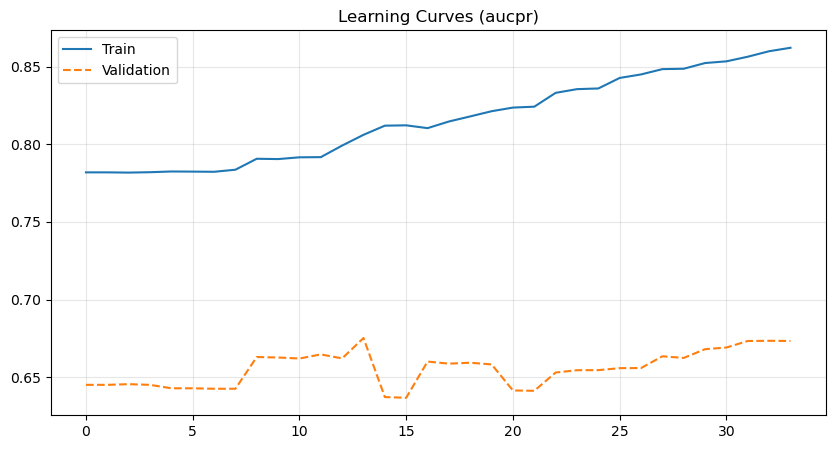

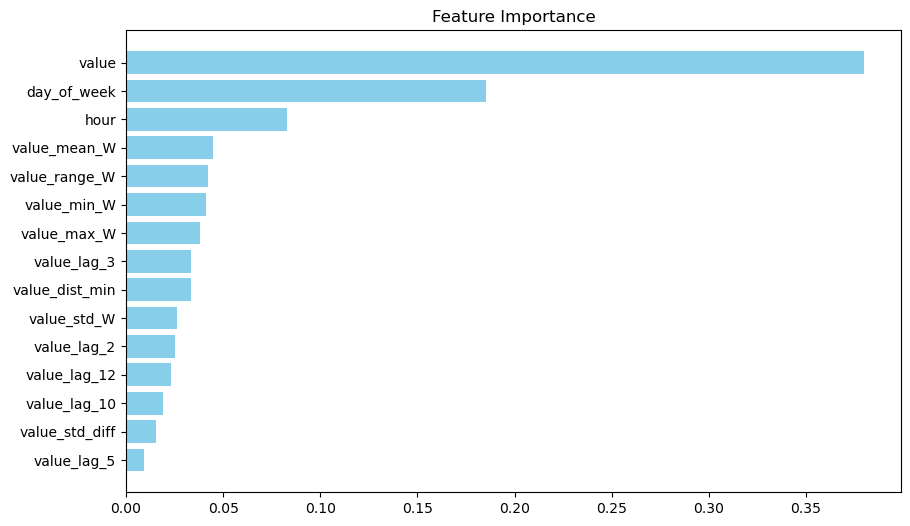

Model saved
Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.74      0.82       672
           1       0.34      0.71      0.46       130

    accuracy                           0.73       802
   macro avg       0.63      0.72      0.64       802
weighted avg       0.83      0.73      0.76       802

ROC AUC Score: 0.7871
PR AUC (AUCPR) Score: 0.6339


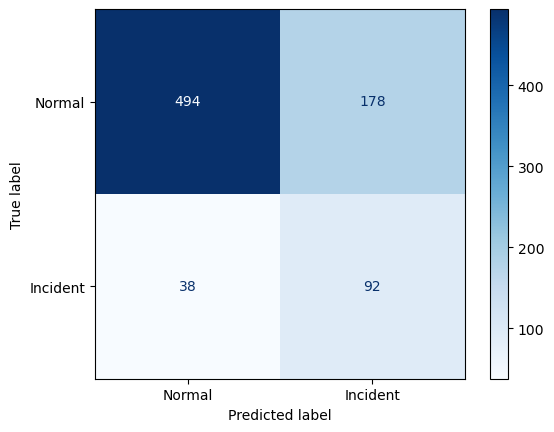

Threshold: 0.7
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       672
           1       0.78      0.47      0.59       130

    accuracy                           0.89       802
   macro avg       0.84      0.72      0.76       802
weighted avg       0.88      0.89      0.88       802

ROC AUC Score: 0.7871
PR AUC (AUCPR) Score: 0.6339


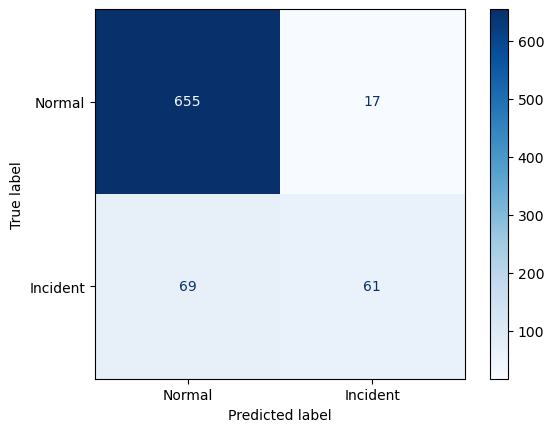

Live prediction test:
Predicted chance of incident in the next 5 steps: 0.39 - No alert.


In [124]:
run_test(W=12,
         H=5,
         file_name=file_name,
         file_path=file_path,
         prediction_thresholds=[0.5,0.7],
         dataset_threshold=25.0)

No. of incidents in Train: 405
No. of incidents in Test: 0


Fold 2/4 | Iteracje:    0 | AUCPR walidacyjne: 0.0000
Fold 3/4 | Iteracje:    0 | AUCPR walidacyjne: 0.3006
Fold 4/4 | Iteracje:    2 | AUCPR walidacyjne: 0.2524

Średnie AUCPR z 4 foldów: 0.1844


/nix/store/dgsa0j0spf1aszsxv8x3bsikmr5dwprg-python3-3.12.12-env/lib/python3.12/site-packages/xgboost/callback.py:264: UserWarning: [20:13:13] WARNING: /build/source/src/metric/auc.cc:324: Dataset is empty, or contains only positive or negative samples.
  score: str = model.eval_set(evals, epoch, self.metric, self._output_margin)
/nix/store/dgsa0j0spf1aszsxv8x3bsikmr5dwprg-python3-3.12.12-env/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


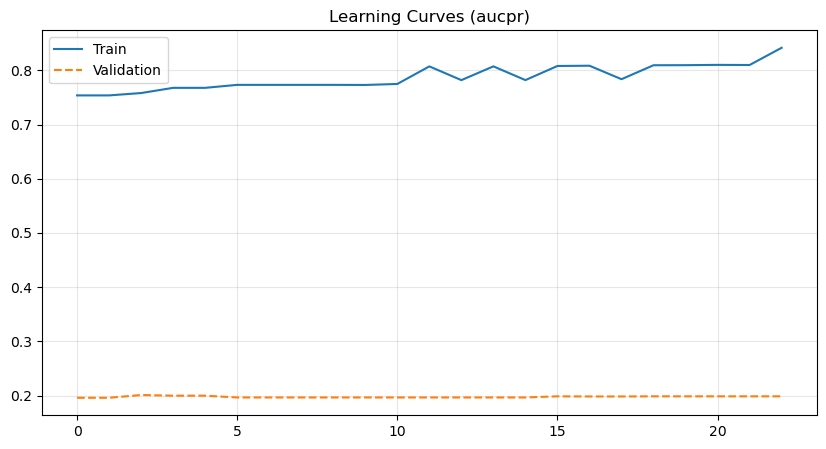

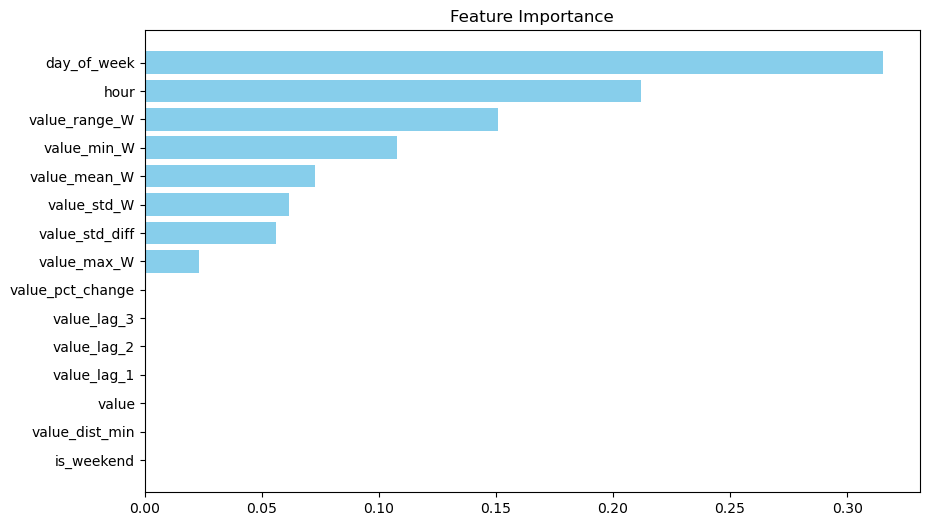

Model saved
Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.81      0.90       802
           1       0.00      0.00      0.00         0

    accuracy                           0.81       802
   macro avg       0.50      0.41      0.45       802
weighted avg       1.00      0.81      0.90       802

ROC AUC Score: N/A
PR AUC (AUCPR) Score: N/A


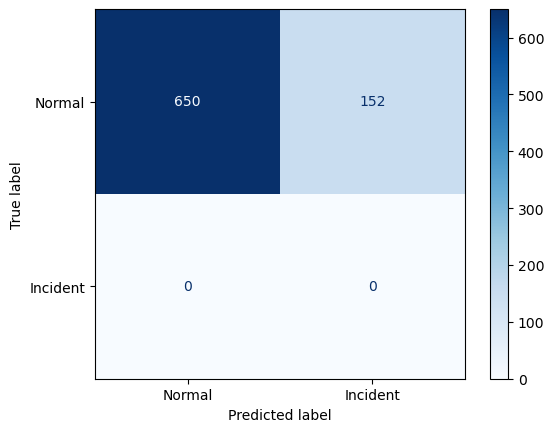

Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       802

    accuracy                           1.00       802
   macro avg       1.00      1.00      1.00       802
weighted avg       1.00      1.00      1.00       802

ROC AUC Score: N/A
PR AUC (AUCPR) Score: N/A


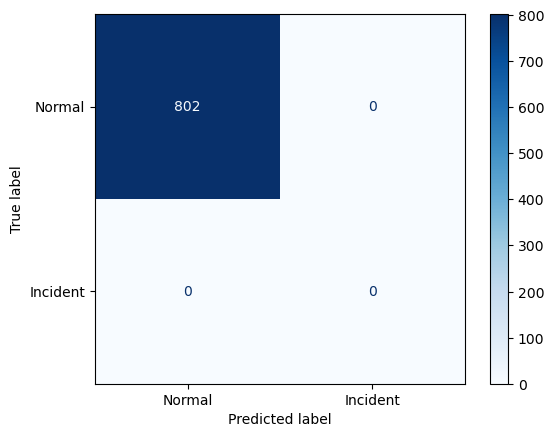

Live prediction test:
Predicted chance of incident in the next 5 steps: 0.52 - ALERT!


In [125]:
run_test(W=12,
         H=5,
         file_name=file_name,
         file_path=file_path,
         prediction_thresholds=[0.5,0.7],
         dataset_threshold=25.0,
         labels_dict=labels_dict)